# Φάση Γ: Classification Models

**Υπεύθυνος:** ML Engineer

**Μοντέλα:**
1. Random Forest
2. SVM


In [3]:
# Φάση Γ: Classification Models (Ισορροπημένες Παράμετροι & Ενσωμάτωση Βαρών)
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (RandomForestClassifier, LinearSVC, NaiveBayes, 
                                       MultilayerPerceptronClassifier, GBTClassifier, LogisticRegression)

print("Εκκίνηση SparkSession...")
spark = SparkSession.builder \
    .appName("Stroke_Classification_Augmented") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

# 1. ΦΟΡΤΩΣΗ ΤΩΝ ΕΜΠΛΟΥΤΙΣΜΕΝΩΝ ΔΕΔΟΜΕΝΩΝ (Από το K-Means)
print("Φόρτωση δεδομένων με Cluster Assignments...")
train_gold = spark.read.parquet("../data/train_gold_with_cluster.parquet")
test_gold = spark.read.parquet("../data/test_gold_with_cluster.parquet")

train_gold = train_gold.withColumn("stroke", train_gold["stroke"].cast(DoubleType()))
test_gold = test_gold.withColumn("stroke", test_gold["stroke"].cast(DoubleType()))

# 2. FEATURE AUGMENTATION: Ενσωμάτωση του Cluster στα Features
print("Ενσωμάτωση του K-Means Cluster στο Feature Vector...")
train_gold = train_gold.withColumn("cluster", F.col("cluster").cast(DoubleType()))
test_gold = test_gold.withColumn("cluster", F.col("cluster").cast(DoubleType()))

assembler = VectorAssembler(inputCols=["features", "cluster"], outputCol="augmented_features")

train_gold = assembler.transform(train_gold).drop("features").withColumnRenamed("augmented_features", "features")
test_gold = assembler.transform(test_gold).drop("features").withColumnRenamed("augmented_features", "features")

train_gold.cache()
test_gold.cache()

# --- ADVANCED TECHNIQUE 1: Cost-Sensitive Learning (Βάρη Κλάσεων) ---
stroke_count = train_gold.filter(F.col("stroke") == 1.0).count()
total_count = train_gold.count()
balance_ratio = (total_count - stroke_count) / stroke_count
train_gold = train_gold.withColumn("class_weight", F.when(F.col("stroke") == 1.0, balance_ratio).otherwise(1.0))

# --- ADVANCED TECHNIQUE 2: Random Undersampling (Data-Centric Approach) ---
minority_df = train_gold.filter(F.col("stroke") == 1.0)
majority_df = train_gold.filter(F.col("stroke") == 0.0).sample(withReplacement=False, fraction=(stroke_count / (total_count - stroke_count)), seed=42)
train_undersampled = minority_df.union(majority_df)

# ==========================================
# 1. ΤΑ 4 ΑΡΧΙΚΑ ΣΟΥ ΜΟΝΤΕΛΑ
# ==========================================
print("Εκπαίδευση 4 Αρχικών Μοντέλων (Με χρήση Cluster Features)...")

# ΠΡΟΣΘΗΚΗ: weightCol="class_weight" ΚΑΙ maxDepth=5 για να μην κάνει overfit
rf = RandomForestClassifier(featuresCol="features", labelCol="stroke", weightCol="class_weight", numTrees=200, maxDepth=8, seed=22390225)
rf_preds = rf.fit(train_gold).transform(test_gold)

svm = LinearSVC(featuresCol="features", labelCol="stroke", maxIter=100)
svm_preds = svm.fit(train_gold).transform(test_gold)

nb = NaiveBayes(featuresCol="features", labelCol="stroke")
nb_preds = nb.fit(train_gold).transform(test_gold)

input_size = len(train_gold.select("features").first()[0])
# Επαναφορά σε μικρότερο δίκτυο
mlp = MultilayerPerceptronClassifier(maxIter=100, layers=[input_size, 16, 8, 2], seed=22390225, featuresCol="features", labelCol="stroke")
mlp_preds = mlp.fit(train_gold).transform(test_gold)


# ==========================================
# 2. ΤΑ ΝΕΑ ΜΟΝΤΕΛΑ (ΕΙΔΙΚΑ ΓΙΑ IMBALANCE)
# ==========================================
print("Εκπαίδευση Νέων Μοντέλων (GBT, Logistic Regression, Undersampled RF)...")

# Επαναφορά σε λιγότερα iterations
gbt = GBTClassifier(featuresCol="features", labelCol="stroke", maxIter=50, maxDepth=4, seed=22390225)
gbt_preds = gbt.fit(train_gold).transform(test_gold)

lr = LogisticRegression(featuresCol="features", labelCol="stroke", weightCol="class_weight", maxIter=100)
lr_preds = lr.fit(train_gold).transform(test_gold)

# Undersampled Random Forest
rf_under = RandomForestClassifier(featuresCol="features", labelCol="stroke", numTrees=100, maxDepth=5, seed=22390225)
rf_under_preds = rf_under.fit(train_undersampled).transform(test_gold)


# --- ΑΠΟΘΗΚΕΥΣΗ ΟΛΩΝ ---
print("Αποθήκευση προβλέψεων...")
rf_preds.select("stroke", "prediction", "probability").write.mode("overwrite").parquet("../data/rf_predictions.parquet")
svm_preds.select("stroke", "prediction", "rawPrediction").write.mode("overwrite").parquet("../data/svm_predictions.parquet")
nb_preds.select("stroke", "prediction", "probability").write.mode("overwrite").parquet("../data/nb_predictions.parquet")
mlp_preds.select("stroke", "prediction", "probability").write.mode("overwrite").parquet("../data/mlp_predictions.parquet")

gbt_preds.select("stroke", "prediction", "probability").write.mode("overwrite").parquet("../data/gbt_predictions.parquet")
lr_preds.select("stroke", "prediction", "probability").write.mode("overwrite").parquet("../data/lr_predictions.parquet")
rf_under_preds.select("stroke", "prediction", "probability").write.mode("overwrite").parquet("../data/rf_under_predictions.parquet")

spark.stop()
print("Η διαδικασία ολοκληρώθηκε επιτυχώς!")

Εκκίνηση SparkSession...
Φόρτωση δεδομένων με Cluster Assignments...
Ενσωμάτωση του K-Means Cluster στο Feature Vector...


26/06/09 20:42:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Εκπαίδευση 4 Αρχικών Μοντέλων (Με χρήση Cluster Features)...


26/06/09 20:42:53 WARN DAGScheduler: Broadcasting large task binary with size 1563.7 KiB
26/06/09 20:42:53 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/06/09 20:42:54 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB


Εκπαίδευση Νέων Μοντέλων (GBT, Logistic Regression, Undersampled RF)...
Αποθήκευση προβλέψεων...


26/06/09 20:43:15 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB


Η διαδικασία ολοκληρώθηκε επιτυχώς!


1. Εκκίνηση SparkSession με FULL ισχύ...
2. Φόρτωση Parquet δεδομένων...


26/06/09 20:47:05 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


3. Δημιουργία ΜΑΖΙΚΟΥ Πλέγματος Παραμέτρων (FULL GRID)...
4. Εκτέλεση μαζικού Cross-Validation (Ώρα για καφέ, θα πάρει μερικά λεπτά)...


26/06/09 20:47:11 WARN DAGScheduler: Broadcasting large task binary with size 1094.3 KiB
26/06/09 20:47:13 WARN DAGScheduler: Broadcasting large task binary with size 1065.0 KiB
26/06/09 20:47:19 WARN DAGScheduler: Broadcasting large task binary with size 1283.8 KiB
26/06/09 20:47:20 WARN DAGScheduler: Broadcasting large task binary with size 1403.5 KiB
26/06/09 20:47:21 WARN DAGScheduler: Broadcasting large task binary with size 1233.6 KiB
26/06/09 20:47:22 WARN DAGScheduler: Broadcasting large task binary with size 1329.2 KiB
26/06/09 20:47:26 WARN DAGScheduler: Broadcasting large task binary with size 1509.7 KiB
26/06/09 20:47:26 WARN DAGScheduler: Broadcasting large task binary with size 1332.7 KiB
26/06/09 20:47:27 WARN DAGScheduler: Broadcasting large task binary with size 1435.7 KiB
26/06/09 20:47:28 WARN DAGScheduler: Broadcasting large task binary with size 1253.0 KiB
26/06/09 20:47:29 WARN DAGScheduler: Broadcasting large task binary with size 1283.8 KiB
26/06/09 20:47:29 WAR


[ΑΠΟΛΥΤΗ ΕΠΙΤΥΧΙΑ] Το βέλτιστο μοντέλο από το FULL SEARCH βρέθηκε:
 -> maxDepth: 12
 -> numTrees: 300
 -> impurity: gini

=================== ΤΕΛΙΚΟ FEATURE IMPORTANCES ===================
                       Feature   Importance
                           age 3.630998e-01
             avg_glucose_level 1.307877e-01
               ever_married_No 8.460053e-02
                           bmi 8.068239e-02
              ever_married_Yes 6.749533e-02
               k-means_cluster 4.247340e-02
            work_type_Govt_job 3.467908e-02
             work_type_Private 2.623718e-02
        smoking_status_Unknown 2.114864e-02
                 gender_Female 1.911132e-02
       work_type_Self-employed 1.638313e-02
                   gender_Male 1.615819e-02
          Residence_type_Urban 1.544817e-02
   smoking_status_never smoked 1.523529e-02
          Residence_type_Rural 1.451783e-02
         smoking_status_smokes 1.214378e-02
smoking_status_formerly smoked 1.204978e-02
            work_t

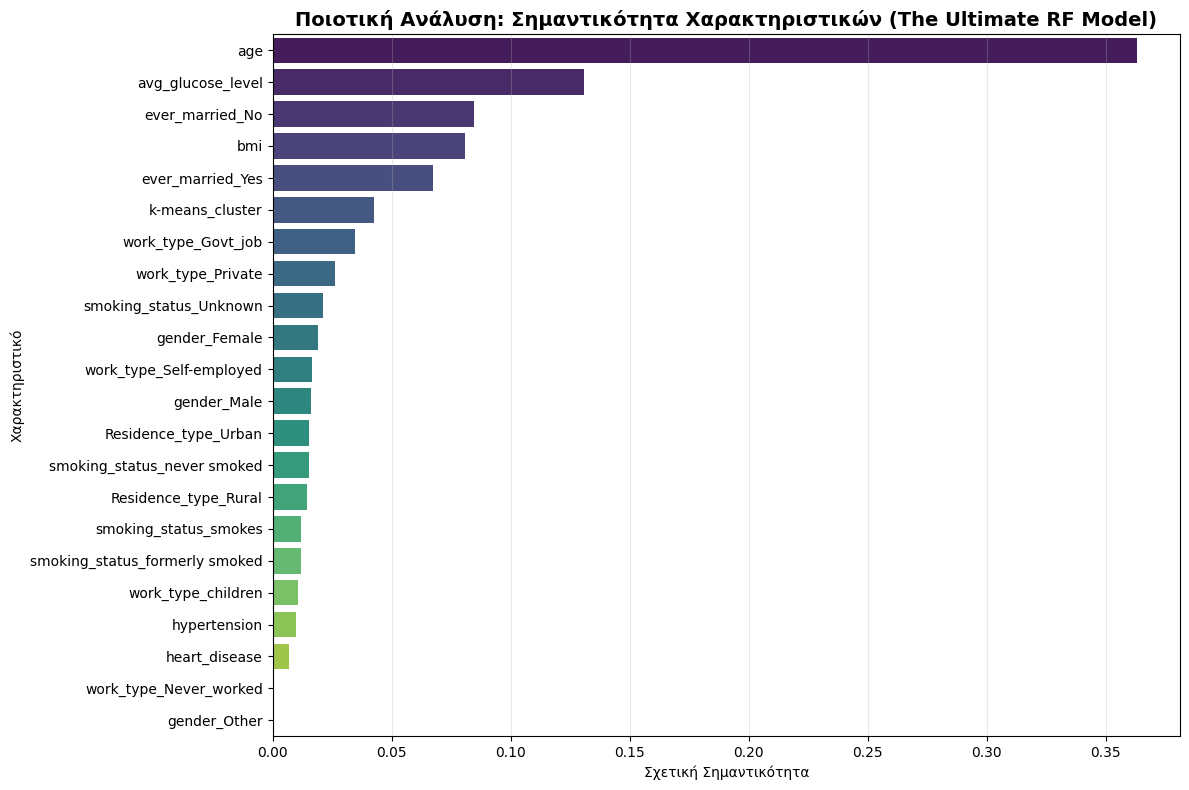

In [4]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Εκκίνηση SparkSession με FULL ισχύ...")
spark = SparkSession.builder \
    .appName("RF_Massive_Hyperparameter_Tuning") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

# Φόρτωση δεδομένων
print("2. Φόρτωση Parquet δεδομένων...")
train_gold = spark.read.parquet("../data/train_gold_with_cluster.parquet")
train_gold = train_gold.withColumn("stroke", train_gold["stroke"].cast(DoubleType()))
train_gold = train_gold.withColumn("cluster", F.col("cluster").cast(DoubleType()))

# Feature Augmentation
assembler = VectorAssembler(inputCols=["features", "cluster"], outputCol="augmented_features")
train_final = assembler.transform(train_gold).drop("features").withColumnRenamed("augmented_features", "features")
train_final.cache()

# Υπολογισμός βαρών για το Imbalance
stroke_count = train_final.filter(F.col("stroke") == 1.0).count()
total_count = train_final.count()
balance_ratio = (total_count - stroke_count) / stroke_count
train_final = train_final.withColumn("class_weight", F.when(F.col("stroke") == 1.0, balance_ratio).otherwise(1.0))

# Ορισμός Βασικού Μοντέλου
rf_base = RandomForestClassifier(featuresCol="features", labelCol="stroke", weightCol="class_weight", seed=22390225)

print("3. Δημιουργία ΜΑΖΙΚΟΥ Πλέγματος Παραμέτρων (FULL GRID)...")
paramGrid = (ParamGridBuilder()
             .addGrid(rf_base.maxDepth, [4, 5, 6, 7, 8, 10, 12])        # 7 επιλογές βάθους
             .addGrid(rf_base.numTrees, [50, 100, 200, 300])           # 4 επιλογές πλήθους δέντρων
             .addGrid(rf_base.impurity, ["gini", "entropy"])           # 2 επιλογές κριτηρίου
             .build())

# Στόχος μας παραμένει η areaUnderROC για να κρατήσουμε ψηλά το True Positive Rate (Recall)
evaluator = BinaryClassificationEvaluator(labelCol="stroke", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# 3-Fold Cross Validation (56 συνδυασμοί x 3 folds = 168 μοντέλα)
cv = CrossValidator(estimator=rf_base,
                    estimatorParamMaps=paramGrid,
                    evaluator=evaluator,
                    numFolds=3,
                    seed=22390225)

print("4. Εκτέλεση μαζικού Cross-Validation (Ώρα για καφέ, θα πάρει μερικά λεπτά)...")
cv_model = cv.fit(train_final)
best_rf = cv_model.bestModel

print("\n===============================================================")
print("[ΑΠΟΛΥΤΗ ΕΠΙΤΥΧΙΑ] Το βέλτιστο μοντέλο από το FULL SEARCH βρέθηκε:")
print(f" -> maxDepth: {best_rf._java_obj.getMaxDepth()}")
print(f" -> numTrees: {best_rf._java_obj.getNumTrees()}")
print(f" -> impurity: {best_rf._java_obj.getImpurity()}")
print("===============================================================")

# Εξαγωγή Σημαντικότητας Χαρακτηριστικών
importances = best_rf.featureImportances.toArray()
feature_labels = [
    "gender_Female", "gender_Male", "gender_Other", "ever_married_Yes", "ever_married_No",
    "work_type_Private", "work_type_Self-employed", "work_type_children", "work_type_Govt_job", "work_type_Never_worked",
    "Residence_type_Urban", "Residence_type_Rural", "smoking_status_never smoked", "smoking_status_Unknown",
    "smoking_status_formerly smoked", "smoking_status_smokes", "age", "hypertension", "heart_disease",
    "avg_glucose_level", "bmi", "k-means_cluster"
]

if len(feature_labels) != len(importances):
    feature_labels = [f"Feature_{i}" for i in range(len(importances))]

importance_df = pd.DataFrame({'Feature': feature_labels, 'Importance': importances}).sort_values(by='Importance', ascending=False)

print("\n=================== ΤΕΛΙΚΟ FEATURE IMPORTANCES ===================")
print(importance_df.to_string(index=False))
print("==================================================================")

# Σχεδίαση
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Ποιοτική Ανάλυση: Σημαντικότητα Χαρακτηριστικών (The Ultimate RF Model)', fontsize=14, fontweight='bold')
plt.xlabel('Σχετική Σημαντικότητα')
plt.ylabel('Χαρακτηριστικό')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

spark.stop()